In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from fastnc import bispectrum
import os
from astropy.cosmology import wCDM

## Baryonic effect on power spectrum
For the 3pt project, we try to avoid the baryon effect by setting scale cut.
The scale cut is determined so that the resultant cosmological parameter is unbiasly recovered.
We use OWLS-AGN-like model to create baryon contaminated data vector. However, there is no theoretical code to simulate that, so we do it by rescale the TNG-300 baryon effect on bispectrum by a factor. 
Where the rescaling factor is obtained by comparing the baryon suppression factors in power spectrum level in OWLS-AGN and TNG-300.

In [3]:
import sys
sys.path.append('../../cosmosis-standard-library/structure/baryon_power_scaling/')
import baryonic

In [4]:
r = baryonic.RatioDatPowerModulator('../../cosmosis-standard-library/structure/baryon_power_scaling/data/logPkRatio_owls_AGN.dat')

Reading baryonic effects table ../../cosmosis-standard-library/structure/baryon_power_scaling/data/logPkRatio_owls_AGN.dat, which has 16 redshift values in


In [5]:
k = np.logspace(-1, 2, 100)
z = np.linspace(0, 1, 10)
p = np.ones((k.size, z.size))
pb= r.modulate(k,z,p)

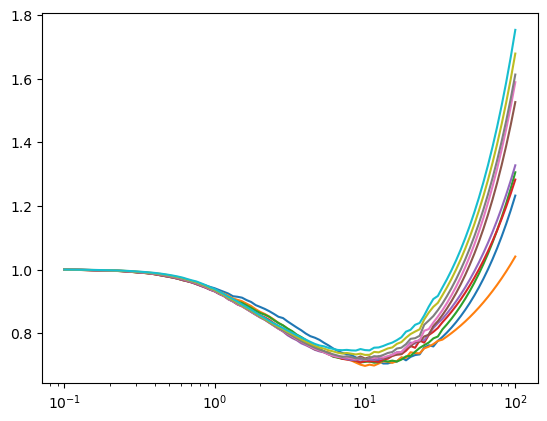

In [6]:
plt.xscale('log')
plt.plot(k, pb)
plt.show()

## Baryonic effect on bispectrum

In [7]:
bs = bispectrum.BispectrumHalofit()

In [8]:
cosmo = bispectrum.wPlanck18
dirname_fastnc = '/Users/sugiyamasunao/documents/projects/fastnc/docs'
k, pklin = np.loadtxt(os.path.join(dirname_fastnc, 'pklin_P18.dat'), unpack=True)
z, lgr = np.loadtxt(os.path.join(dirname_fastnc, 'lgr_P18.dat'), unpack=True)

In [9]:
bs.set_cosmology(cosmo)
bs.set_pklin(k, pklin)
bs.set_lgr(z, lgr)

In [18]:
k = k1 = k2 = k3 = np.logspace(-1, 2, 200)
z = np.ones_like(k1) * 1.0

bs.set_baryon_param({'fb':0.0})
bk_dm = bs.matter_bispectrum(k1, k2, k3, z)
bs.set_baryon_param({'fb':1.0})
bk_tng300 = bs.matter_bispectrum(k1, k2, k3, z)
bs.set_baryon_param({'fb':1.5})
bk_owls = bs.matter_bispectrum(k1, k2, k3, z)

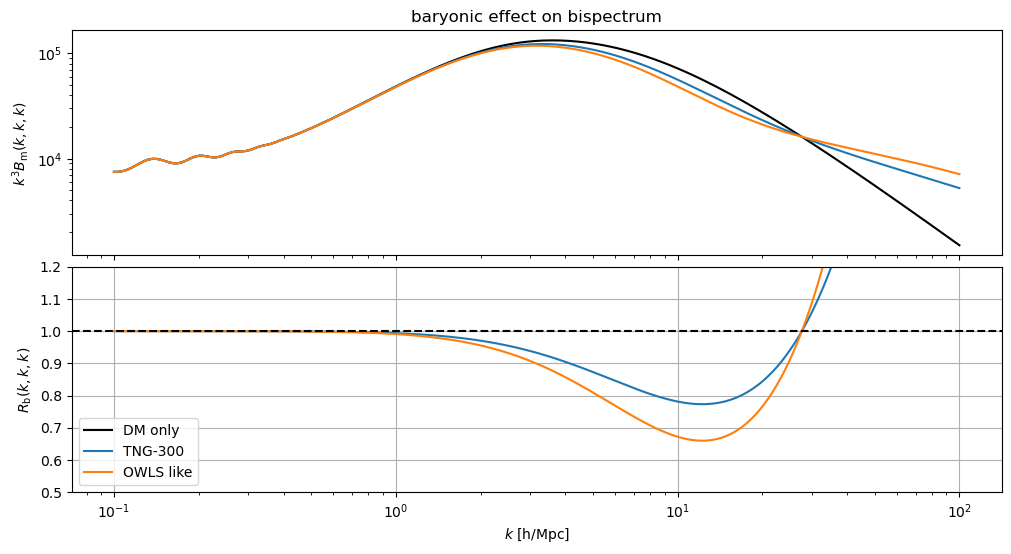

In [19]:
fig, axes = plt.subplots(2,1, figsize=(12, 6), sharex=True)
plt.subplots_adjust(hspace=0.05)
axes[0].set_title('baryonic effect on bispectrum')
axes[0].loglog(k, k**3*bk_dm, 'k')
axes[0].loglog(k, k**3*bk_tng300)
axes[0].loglog(k, k**3*bk_owls)
axes[0].set_ylabel(r'$k^3B_{\rm m}(k,k,k)$')
axes[1].semilogx(np.nan, color='k', label='DM only')
axes[1].semilogx(k, bk_tng300/bk_dm, label='TNG-300')
axes[1].semilogx(k, bk_owls/bk_dm, label='OWLS like')
axes[1].axhline(1.0, color='k', ls='--')
axes[1].set_ylim(0.5, 1.2)
axes[1].legend()
axes[1].set_ylabel(r'$R_{\rm b}(k,k,k)$')
axes[1].set_xlabel(r'$k$ [h/Mpc]')
axes[1].grid()
plt.show()